In [1]:
from cndlles.preprocess import preprocess
from cndlles.preprocess import rotate_sample
from cndlles.preprocess import my_reshape
from cndlles.preprocess import cut_sponge
from cndlles.torch_arch import *

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import torch

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
size=3  # Horizontal size of input planes, always 3 in vertical
shape = (9, size, size)

Ri_pct = 0.25  # Percent of first hidden layer features that are due to tranforming Ri input
Nhid = [32,16,8]  # Multiplicity of hidden layers

In [5]:
loadFile='../training_C4DNN/trainedModels/C4_ReExtrap_'
baseline_loadFile='../baseline/trainedModels/baseline_noDataAug_ReExtrap_'
dataAug_loadFile='../baseline/trainedModels/baseline_dataAug_ReExtrap_'

## Training datasets
files=["coarse4x1026_Re900.nc", "coarse4x2052_Re1800.nc" ] # "coarse4x1026_Re1800.nc"]

for n in range(len(files)):
    isep = files[n].index('_')
    loadFile = loadFile+files[n][6:isep]+files[n][isep+1:-3]+'_'
    baseline_loadFile = baseline_loadFile+files[n][6:isep]+files[n][isep+1:-3]+'_'
    dataAug_loadFile = dataAug_loadFile+files[n][6:isep]+files[n][isep+1:-3]+'_'

loadFile=loadFile+'1.pt'
baseline_loadFile=baseline_loadFile+'1.pt'
dataAug_loadFile=dataAug_loadFile+'1.pt'

print('inference from '+loadFile)
print('inference from '+baseline_loadFile)
print('inference from '+dataAug_loadFile)

inference from ../training_C4DNN/trainedModels/C4_ReExtrap_4x1026Re900_4x2052Re1800_1.pt
inference from ../baseline/trainedModels/baseline_noDataAug_ReExtrap_4x1026Re900_4x2052Re1800_1.pt
inference from ../baseline/trainedModels/baseline_dataAug_ReExtrap_4x1026Re900_4x2052Re1800_1.pt


### 1. Define C4DNN

In [6]:
model=CNDNN(Nhid, Ri_pct = Ri_pct,N=4,size=size).float().to(device)
model.load_state_dict(torch.load(loadFile, map_location=device))

<All keys matched successfully>

### 1. Define baselines

In [7]:
Nhid = [2*32,2*16,2*8]  # Depth of hidden layers
baseline=baselineDNN(Nhid, shape, Ri_pct=Ri_pct).float().to(device)
dataAug=baselineDNN(Nhid, shape, Ri_pct=Ri_pct).float().to(device)

In [8]:
baseline.load_state_dict(torch.load(baseline_loadFile, map_location=device))

<All keys matched successfully>

In [9]:
dataAug.load_state_dict(torch.load(dataAug_loadFile, map_location=device))

<All keys matched successfully>

In [10]:
model.eval()
baseline.eval()
dataAug.eval()

baselineDNN(
  (u_in): Conv2d(9, 48, kernel_size=(3, 3), stride=(1, 1), padding=valid, bias=False)
  (Ri_in): Linear(in_features=1, out_features=16, bias=True)
  (ops): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=False)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=False)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=6, bias=False)
  )
  (change_basis): Linear(in_features=6, out_features=6, bias=False)
)

In [11]:
# Test (reported statistics) and Validation (early stopping) data
testFiles=["coarse4x3078_Re2700.nc"]
testfileUgs=[0.075]
testfileRes=[60000.]
tauScale = testfileUgs[0]**2/testfileRes[0]

testfilemaskpercents=[1]

utest, Ritest, ytest, _ = preprocess(testFiles, testfilemaskpercents, testfileUgs, testfileRes,
                                                size, None, reshape = False)


coarse4x3078_Re2700.nc
Number of samples is 141312
output shape is (141312, 6)
input shape was (141312, 3, 3, 3, 3) + (141312, 1, 1, 1)
input shape is (141312, 3, 3, 3, 3) + (141312, 1, 1, 1)


In [12]:
u_rotated = np.empty(utest.shape)
Ri_rotated = Ritest
y_rotated = np.empty(ytest.shape)

for i in range(y_rotated.shape[0]):
    u_rotated[i], y_rotated[i] = rotate_sample( utest[i], ytest[i], 3)

utest = my_reshape(utest)
u_rotated = my_reshape(u_rotated)

In [13]:
def get_xyplane_true(y,scale,nx,ny,nz,nt,kplot,tplot,krot=0):
    xyplane=np.empty((nx,ny,y.shape[1]))
    for i in range(nx):
        for j in range(ny):
            xyplane[i,j]=y[i*ny*nz*nt+j*nz*nt+kplot*nt+tplot]*scale
    
    return np.rot90(xyplane,k=krot)

def get_xyplane_model(model,u,Ri,scale,nx,ny,nz,nt,kplot,tplot,krot=0):
    xyplane=np.empty((nx,ny,6))
    for i in range(nx):
        for j in range(ny):            
            xyplane[i,j]=model(torch.from_numpy(u[i*ny*nz*nt+j*nz*nt+kplot*nt+tplot]).float().unsqueeze(0).to(device), 
                               torch.from_numpy(Ri[i*ny*nz*nt+j*nz*nt+kplot*nt+tplot]).float().unsqueeze(0).to(device)
                              ).detach().cpu().numpy().squeeze()
            xyplane[i,j]=xyplane[i,j]*scale
    return np.rot90(xyplane,k=krot)

def get_grid(file):# Any of the below could be changed to inputs of the function
    path="/glade/u/home/adac/work/DNStoLES/coarseData/"

    ds=xr.open_dataset(path+file,decode_times=0)
    print(ds)

    x=ds['x'].values
    y=ds['y'].values
    z=cut_sponge(ds['z'].values)
    
    return x,y,z

In [14]:
xx,yy,z=get_grid(testFiles[0])

<xarray.Dataset> Size: 17MB
Dimensions:  (z: 64, y: 32, x: 32, time: 3)
Coordinates:
  * z        (z) float64 512B 0.5648 0.8473 1.13 1.412 ... 17.79 18.07 18.36
  * y        (y) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * x        (x) float64 256B 0.4279 1.284 2.14 2.995 ... 24.39 25.25 26.1 26.96
  * time     (time) int64 24B 1368000 1377000 1386000
Data variables:
    u        (z, y, x, time) float64 2MB ...
    v        (z, y, x, time) float64 2MB ...
    w        (z, y, x, time) float64 2MB ...
    tau11    (z, y, x, time) float64 2MB ...
    tau22    (z, y, x, time) float64 2MB ...
    tau33    (z, y, x, time) float64 2MB ...
    tau12    (z, y, x, time) float64 2MB ...
    tau13    (z, y, x, time) float64 2MB ...
    tau23    (z, y, x, time) float64 2MB ...
    b        (z, y, x, time) float64 2MB ...
    p        (z, y, x, time) float64 2MB ...


In [15]:
nz=int(0.75*64-2) # 64 vertical levels is from the netCDF, recall we cut the top 25% laminar la
ny=32
nx=32
nt=3

In [16]:
# y_plane=get_xyplane_true(ytest,tauScale,nx,ny,nz,nt,kplot,tplot)
# y_baseline_plane=get_xyplane_model(baseline,utest,Ritest,tauScale,nx,ny,nz,nt,kplot,tplot)
# y_baseline_aug_plane=get_xyplane_model(dataAug,utest,Ritest,tauScale,nx,ny,nz,nt,kplot,tplot)
# y_e2cnn_plane=get_xyplane_model(model,utest,Ritest,tauScale,nx,ny,nz,nt,kplot,tplot)
# #y_e2cnn_aug_plane=get_xyplane_model(e2cnn_aug,utest,Ritest,tauScale,nx,ny,nz,nt,kplot,tplot)

# y_rotated_plane=get_xyplane_true(y_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)
# y_rotated_baseline_plane=get_xyplane_model(baseline,u_rotated,Ri_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)
# y_rotated_baseline_aug_plane=get_xyplane_model(dataAug,u_rotated,Ri_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)
# y_rotated_e2cnn_plane=get_xyplane_model(model,u_rotated,Ri_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)
# #y_rotated_e2cnn_aug_plane=get_xyplane_model(e2cnn_aug,u_rotated,Ri_rotated,tauScale_rotated,nx,ny,nz,nt,kplot,tplot,krot=3)

In [17]:
kplot=np.argmin(np.abs(z-2))
print(kplot)
print(z[kplot])

kplot+=1
print(kplot)
print(z[kplot])

5
1.976936104588006
6
2.259355547718537


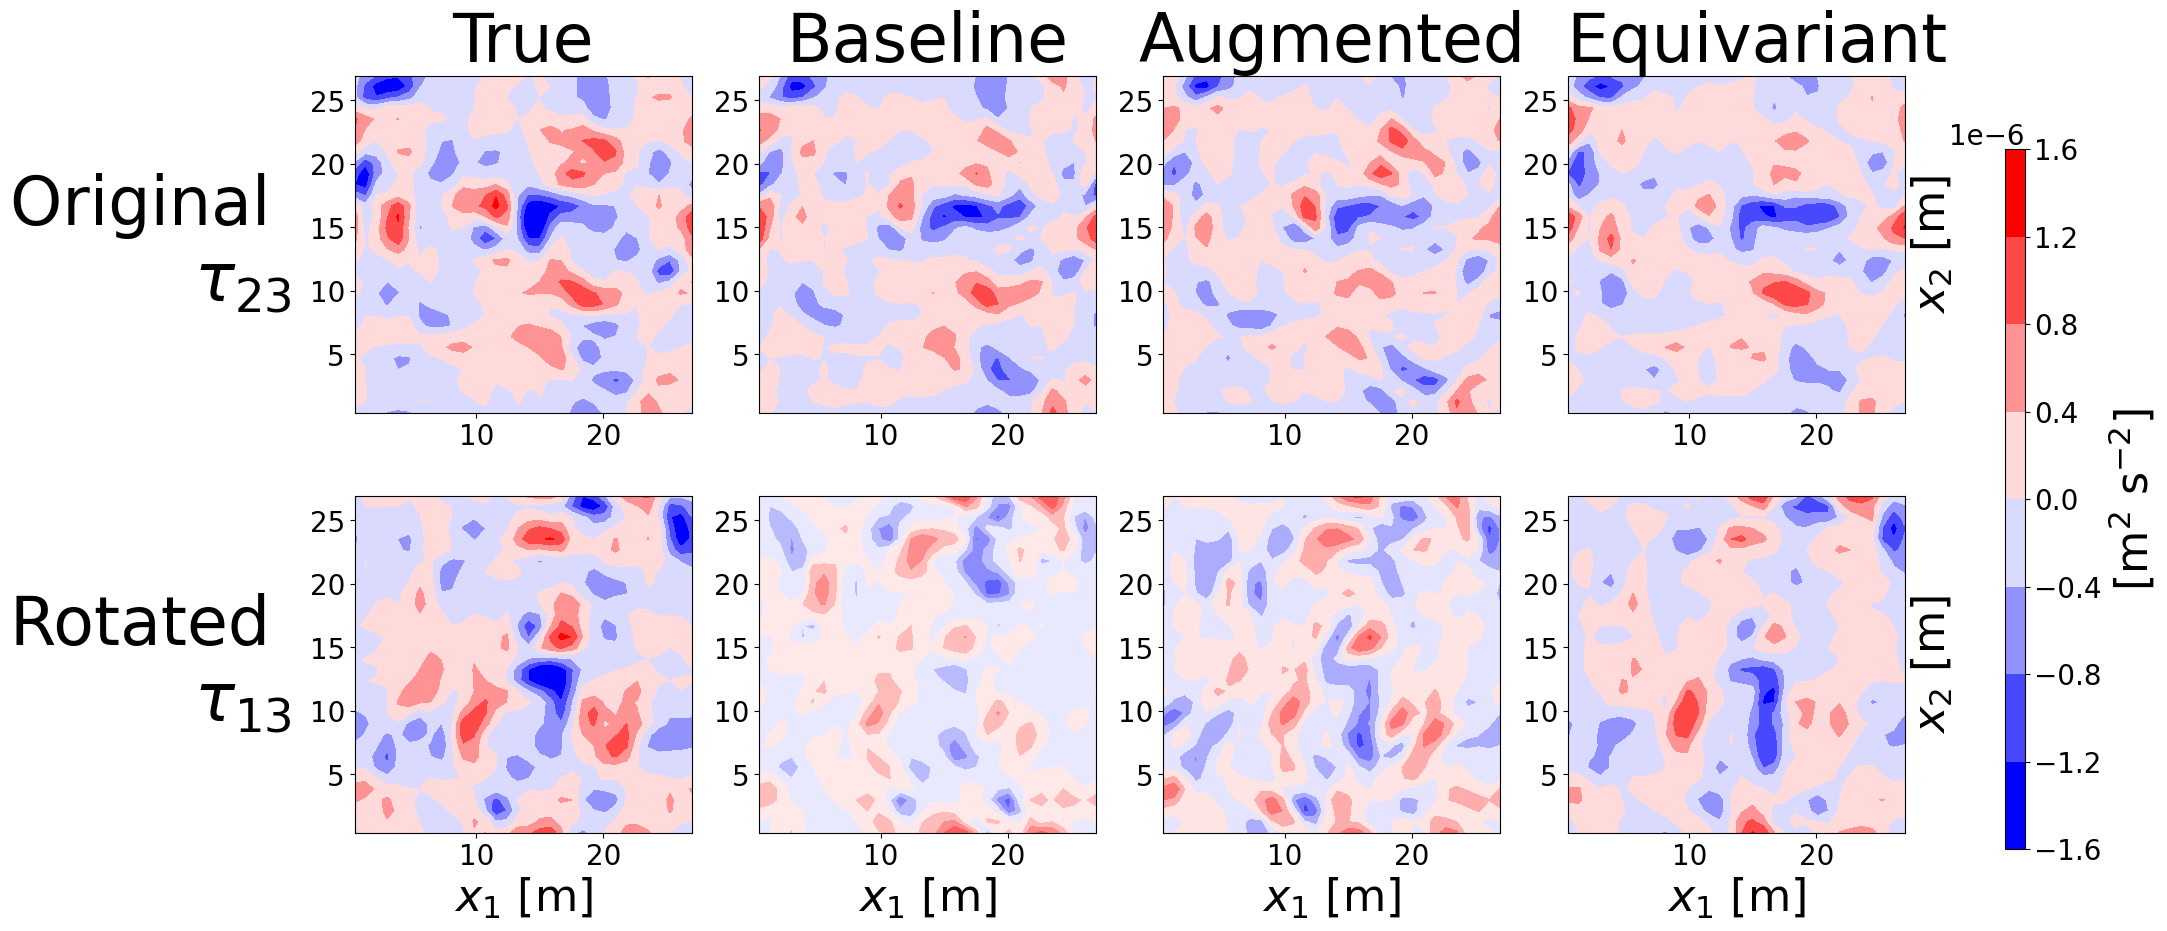

In [18]:
for kplot in [6]:#range(10):
    for tplot in [1]:#range(0,3):
        y_plane=get_xyplane_true(ytest,tauScale,nx,ny,nz,nt,kplot,tplot)
        y_baseline_plane=get_xyplane_model(baseline,utest,Ritest,tauScale,nx,ny,nz,nt,kplot,tplot)
        y_baseline_aug_plane=get_xyplane_model(dataAug,utest,Ritest,tauScale,nx,ny,nz,nt,kplot,tplot)
        y_e2cnn_plane=get_xyplane_model(model,utest,Ritest,tauScale,nx,ny,nz,nt,kplot,tplot)

        y_rotated_plane=get_xyplane_true(y_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)
        y_rotated_baseline_plane=get_xyplane_model(baseline,u_rotated,Ri_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)
        y_rotated_baseline_aug_plane=get_xyplane_model(dataAug,u_rotated,Ri_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)
        y_rotated_e2cnn_plane=get_xyplane_model(model,u_rotated,Ri_rotated,tauScale,nx,ny,nz,nt,kplot,tplot,krot=3)

        xyPlanes=np.array([[y_plane,y_baseline_plane,y_baseline_aug_plane,y_e2cnn_plane],
        [y_rotated_plane,y_rotated_baseline_plane,y_rotated_baseline_aug_plane,y_rotated_e2cnn_plane]])
        
        # vmax=3*np.std(y_plane[:,:,4])
        #print(tplot)
        #print(vmax)
        vmax=1.4e-6
        vmin=-vmax

        model_text=['True','Baseline','Augmented','  '+'Equivariant']
        var_text=['Original \n'+r'$\tau_{23}$', 'Rotated \n'+ r'$\tau_{13}$']
        fig,axs=plt.subplots(xyPlanes.shape[0],xyPlanes.shape[1],figsize=(20,10))
        for im in range(xyPlanes.shape[1]):
            for ir in range(xyPlanes.shape[0]):
                c1=axs[ir,im].contourf(xx,yy,xyPlanes[ir,im,:,:,4-2*ir].T,vmin=vmin,vmax=vmax,cmap='bwr')#,shading='gouraud')
                c1.set_clim(vmin,vmax)
                axs[ir,im].set_aspect('equal')
                axs[ir,im].tick_params(labelsize=20)
                
        for im in range(xyPlanes.shape[1]):
            axs[0,im].set_title(model_text[im],fontsize=48)
            axs[-1,im].set_xlabel(r'$x_1$ [m]',fontsize=32)

        pad = 5
        for ir in range(xyPlanes.shape[0]):
            axs[ir,0].annotate(var_text[ir], xy=(0, 0.5), xytext=(-axs[ir,0].yaxis.labelpad - pad, 0),
                        xycoords=axs[ir,0].yaxis.label, textcoords='offset points',
                        fontsize=48, ha='right', va='center')
            axs[ir,-1].yaxis.set_label_position("right")
            axs[ir,-1].set_ylabel(r'$x_2$ [m]',fontsize=32)

        c2=c1
        fig.subplots_adjust(right=0.9)
        cbar_ax = fig.add_axes([0.95, 0.1, 0.01, 0.7])
        cbar=fig.colorbar(c2,cax=cbar_ax)#,boundaries=np.linspace(vmin,vmax,num=9))
        cbar_ax.set_ylabel(r'[m$^2$ s$^{-2}$]',fontsize=32)
        cbar_ax.yaxis.offsetText.set_fontsize(20)
        cbar_ax.tick_params(labelsize=20)
        
        plt.savefig('rotContour_t'+str(tplot)+'_k'+str(kplot)+'.png', bbox_inches="tight",format='png', transparent=True)
        del(fig,axs)